In [ ]:
!pip install shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

print("All libraries loaded succesfully!")

All libraries loaded succesfully!


In [ ]:
url = ("https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data")

columns = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach",
"exang", "oldpeak", "slope", "ca", "thal", "target"]

df = pd.read_csv(url, names=columns, na_values="?")

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Dataset shape: (303, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
#check for missing values
print("Missing values per column:")
print(df.isnull().sum())

#check class distribution
print("\nTarget value counts:")
print(df["target"].value_counts())

#convert target to binary (0 = no disease, 1 = disease)
df["target"] = (df["target"] > 0).astype(int)

print("\nAfter converting to binary:")
print(df["target"].value_counts())

#Drop rows with missing values
df= df.dropna()
print("\nDataset shape after dropping missing values:", df.shape)


Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Target value counts:
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

After converting to binary:
target
0    164
1    139
Name: count, dtype: int64

Dataset shape after dropping missing values: (297, 14)


In [ ]:
#separate features (x) and target (y)
X = df.drop("target", axis = 1)
y = df["target"]

#split into training and testing sets(80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (237, 13)
Testing set size: (60, 13)


In [ ]:
classes = np.array([0,1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = {0: weights[0], 1: weights [1]}

model = RandomForestClassifier(
    n_estimators=100,
    class_weight=class_weight_dict,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# make predictions on the test set
y_pred = model.predict(X_test)

# accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy,4))

# detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# AUC score
y_prob = model.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, y_prob)
print("AUC Score:", round(auc, 4))

Accuracy: 0.8833

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90        36
           1       0.84      0.88      0.86        24

    accuracy                           0.88        60
   macro avg       0.88      0.88      0.88        60
weighted avg       0.88      0.88      0.88        60

Confusion Matrix:
[[32  4]
 [ 3 21]]
AUC Score: 0.9398


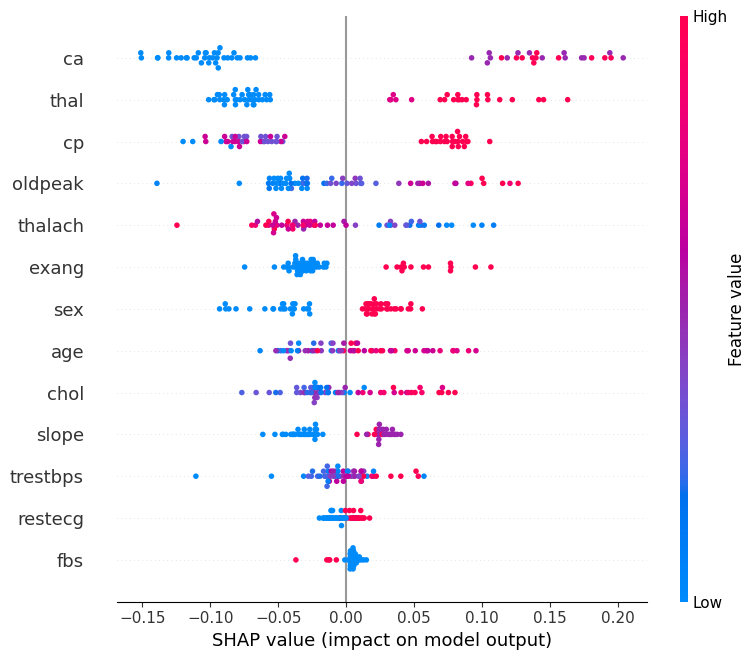

In [ ]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values[:,:, 1], X_test,
                  feature_names=["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal"])


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3,5, None],
    "min_samples_split": [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight=class_weight_dict, random_state=42),
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best AUC score:", round(grid_search.best_score_, 4))

best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
y_prob_tuned = best_model.predict_proba(X_test)[:, 1]

print("Tuned Accuracy:", round(accuracy_score(y_test, y_pred_tuned), 4))
print("Tuned AUC Score:", round(roc_auc_score(y_test, y_prob_tuned), 4))

Best parameters: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 50}
Best AUC score: 0.8934
Tuned Accuracy: 0.85
Tuned AUC Score: 0.9468


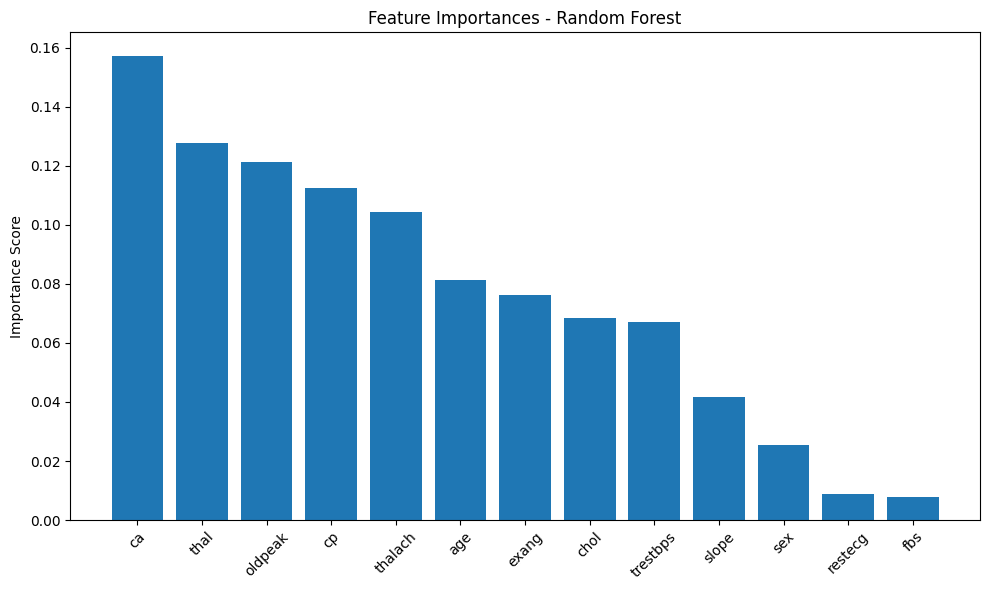

In [ ]:
importances = best_model.feature_importances_
feature_names = ["age", "sex", "cp", "trestbps", "chol",
                 "fbs", "restecg", "thalach", "exang",
                 "oldpeak", "slope", "ca", "thal"]
indices = np.argsort(importances)[::-1]

plt. figure(figsize=(10, 6))
plt.bar(range(13), importances[indices])
plt.xticks(range(13), [feature_names[i] for i in indices], rotation=45)
plt.title("Feature Importances - Random Forest")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()
